In [ ]:
from google.colab import auth
auth.authenticate_user()
print("Authenticated.")

Authenticated.


In [ ]:
from google.cloud import bigquery
PROJECT_ID = "web-science-gdelt"
client = bigquery.Client(project=PROJECT_ID)
print("BigQuery client ready.")

BigQuery client ready.


In [ ]:
query = """
SELECT
  DATE,
  SourceCommonName,
  DocumentIdentifier,
  V2Tone,
  V2Themes,
  CASE WHEN (
       V2Themes LIKE '%EPU_CATS_REGULATION%'
    OR V2Themes LIKE '%EPU_POLICY_LAW%'
    OR V2Themes LIKE '%LEGISLATION%'
    OR V2Themes LIKE '%WB_831_GOVERNANCE%'
    OR V2Themes LIKE '%WB_2089_ETHICS_AND_CODES_OF_CONDUCT%'
    OR V2Themes LIKE '%WB_845_LEGAL_AND_REGULATORY_FRAMEWORK%'
    OR V2Themes LIKE '%WB_851_INTELLECTUAL_PROPERTY_RIGHTS%'
    OR V2Themes LIKE '%WB_838_PUBLIC_ACCOUNTABILITY_MECHANISMS%'
    OR V2Themes LIKE '%WB_279_ICT_STRATEGY_POLICY_AND_REGULATION%'
    OR V2Themes LIKE '%WB_282_ICT_POLICY_REGULATORY_FRAMEWORK%'
    OR V2Themes LIKE '%EPU_POLICY_REGULATION%'
    OR LOWER(DocumentIdentifier) LIKE '%-regulat%'
    OR LOWER(DocumentIdentifier) LIKE '%-policy-%'
    OR LOWER(DocumentIdentifier) LIKE '%-legislat%'
    OR LOWER(DocumentIdentifier) LIKE '%-governance-%'
    OR LOWER(DocumentIdentifier) LIKE '%-safety-%'
    OR LOWER(DocumentIdentifier) LIKE '%-security-%'
    OR LOWER(DocumentIdentifier) LIKE '%-threat%'
    OR LOWER(DocumentIdentifier) LIKE '%-warns-%'
    OR LOWER(DocumentIdentifier) LIKE '%-warning-%'
    OR LOWER(DocumentIdentifier) LIKE '%-ethic%'
    OR LOWER(DocumentIdentifier) LIKE '%-privacy-%'
    OR LOWER(DocumentIdentifier) LIKE '%-rights-%'
    OR LOWER(DocumentIdentifier) LIKE '%-oversight-%'
    OR LOWER(DocumentIdentifier) LIKE '%-copyright%'
    OR LOWER(DocumentIdentifier) LIKE '%-lawsuit%'
    OR LOWER(DocumentIdentifier) LIKE '%-banned-%'
    OR LOWER(DocumentIdentifier) LIKE '%-ban-%'
    OR LOWER(DocumentIdentifier) LIKE '%-ai-act%'
    OR LOWER(DocumentIdentifier) LIKE '%-regulation%'
  ) THEN 1 ELSE 0 END AS governance_flag
FROM `gdelt-bq.gdeltv2.gkg_partitioned`
WHERE _PARTITIONTIME >= TIMESTAMP("2022-11-01")
  AND _PARTITIONTIME < TIMESTAMP("2026-06-15")
  AND DATE >= 20221101000000
  AND (TranslationInfo IS NULL OR TranslationInfo = '')
  AND (
       LOWER(DocumentIdentifier) LIKE '%chatgpt%'
    OR LOWER(DocumentIdentifier) LIKE '%openai%'
    OR LOWER(DocumentIdentifier) LIKE '%gpt-4%'
    OR LOWER(DocumentIdentifier) LIKE '%generative-ai%'
    OR LOWER(DocumentIdentifier) LIKE '%generative-artificial-intelligence%'
    OR LOWER(DocumentIdentifier) LIKE '%large-language-model%'
    OR LOWER(DocumentIdentifier) LIKE '%-gemini-%'
    OR LOWER(DocumentIdentifier) LIKE '%-anthropic%'
    OR LOWER(DocumentIdentifier) LIKE '%anthropic-%'
    OR LOWER(DocumentIdentifier) LIKE '%anthropic.%'
    OR LOWER(DocumentIdentifier) LIKE '%-claude-%'
    OR LOWER(DocumentIdentifier) LIKE '%copilot%'
    OR LOWER(DocumentIdentifier) LIKE '%-llama-%'
    OR LOWER(DocumentIdentifier) LIKE '%-grok-%'
    OR LOWER(DocumentIdentifier) LIKE '%foundation-model%'
    OR LOWER(DocumentIdentifier) LIKE '%frontier-ai%'
    OR LOWER(DocumentIdentifier) LIKE '%frontier-model%'
    OR LOWER(DocumentIdentifier) LIKE '%-llm-%'
    OR LOWER(DocumentIdentifier) LIKE '%-llms-%'
  )
  AND LOWER(DocumentIdentifier) NOT LIKE '%/category/%'
  AND LOWER(DocumentIdentifier) NOT LIKE '%/tag/%'
  AND LOWER(DocumentIdentifier) NOT LIKE '%horoscope%'
  AND LOWER(DocumentIdentifier) NOT LIKE '%zodiac%'
"""

df = client.query(query).to_dataframe()
print(f"Pulled {len(df):,} rows")
df.head()

Pulled 273,631 rows


,DATE,SourceCommonName,DocumentIdentifier,V2Tone,V2Themes,governance_flag
0,20240210233000,breitbart.com,https://www.breitbart.com/economy/2024/02/10/o...,"1.84615384615385,3.07692307692308,1.2307692307...","WB_1921_PRIVATE_SECTOR_DEVELOPMENT,1225;WB_346...",0
1,20230104234500,shacknews.com,https://www.shacknews.com/article/133568/micro...,"0.395256916996047,2.17391304347826,1.778656126...",None,0
2,20240210234500,scmp.com,https://www.scmp.com/tech/tech-trends/article/...,"2.22929936305732,3.5031847133758,1.27388535031...",None,0
3,20230105234500,wirralglobe.co.uk,https://www.wirralglobe.co.uk/news/national/uk...,"-2.02702702702703,4.05405405405405,6.081081081...","CRISISLEX_T11_UPDATESSYMPATHY,647;GENERAL_HEAL...",0
4,20230105234500,wandsworthguardian.co.uk,https://www.wandsworthguardian.co.uk/news/nati...,"-2.02702702702703,4.05405405405405,6.081081081...","CRISISLEX_T11_UPDATESSYMPATHY,647;GENERAL_HEAL...",0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
output_path = "/content/drive/MyDrive/genai_governance_raw.csv"
df.to_csv(output_path, index=False)
print(f"Saved {len(df):,} rows to {output_path}")

Saved 273,631 rows to /content/drive/MyDrive/genai_governance_raw.csv


In [ ]:
import pandas as pd

# Reload from Drive (so this works even after a session reset)
df = pd.read_csv("/content/drive/MyDrive/genai_governance_raw.csv")

print(f"Total rows: {len(df):,}")
print(f"Governance-flagged: {df['governance_flag'].sum():,} ({100*df['governance_flag'].mean():.1f}%)")

# Convert DATE to real dates and check the span
df['date'] = pd.to_datetime(df['DATE'].astype(str).str[:8], format='%Y%m%d')
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

# How much is exact-duplicate syndication? (same URL slug appearing many times)
print(f"Unique URLs: {df['DocumentIdentifier'].nunique():,}")
print(f"Duplicate rows: {len(df) - df['DocumentIdentifier'].nunique():,}")

# Monthly volume — a first peek at RQ1
df['month'] = df['date'].dt.to_period('M')
print("\nArticles per month (first/last few):")
monthly = df.groupby('month').size()
print(monthly.head())
print(monthly.tail())

Total rows: 273,631
Governance-flagged: 91,793 (33.5%)
Date range: 2022-11-01 to 2026-06-14
Unique URLs: 273,392
Duplicate rows: 239

Articles per month (first/last few):
month
2022-11     541
2022-12     877
2023-01    3250
2023-02    5838
2023-03    6319
Freq: M, dtype: int64
month
2026-02     9272
2026-03     9501
2026-04    11065
2026-05     9181
2026-06     5902
Freq: M, dtype: int64


In [ ]:
import pandas as pd
import re

# Reload to be safe after any session reset
df = pd.read_csv("/content/drive/MyDrive/genai_governance_raw.csv")

def url_to_headline(url):
    url = str(url).lower()
    # 1. strip scheme and query string
    url = re.sub(r'^https?://', '', url)
    url = re.split(r'\?', url)[0]
    # 2. drop the domain (everything up to and including the first /)
    parts = url.split('/', 1)
    path = parts[1] if len(parts) > 1 else parts[0]
    # 3. take the longest path segment — that's almost always the headline slug
    segments = [s for s in path.split('/') if s]
    if not segments:
        return ""
    slug = max(segments, key=len)
    # 4. strip file extensions (.html .cms .ece .htm .aspx etc.)
    slug = re.sub(r'\.(html?|cms|ece|aspx?|php|stm)$', '', slug)
    # 5. remove standalone number blocks (article IDs, dates, story numbers)
    slug = re.sub(r'[_\-]\d{4,}', ' ', slug)   # -123031700145, _98722849
    slug = re.sub(r'\b\d{4,}\b', ' ', slug)    # bare long numbers
    # 6. hyphens/underscores -> spaces
    slug = re.sub(r'[\-_]+', ' ', slug)
    # 7. collapse leftover punctuation and whitespace
    slug = re.sub(r'[^a-z0-9 ]+', ' ', slug)
    slug = re.sub(r'\s+', ' ', slug).strip()
    return slug

df['headline_text'] = df['DocumentIdentifier'].apply(url_to_headline)

# Quality check: how usable is the extracted text?
df['word_count'] = df['headline_text'].str.split().str.len()

print(f"Total rows: {len(df):,}")
print(f"Empty/blank headlines: {(df['word_count'] == 0).sum():,}")
print(f"Very short (1-2 words, likely junk): {(df['word_count'].between(1,2)).sum():,}")
print(f"Usable (3+ words): {(df['word_count'] >= 3).sum():,} ({100*(df['word_count']>=3).mean():.1f}%)")
print(f"Median words per headline: {df['word_count'].median():.0f}")

print("\n--- 25 random samples (URL -> extracted headline) ---")
for _, row in df.sample(25, random_state=1).iterrows():
    print(f"[{row['word_count']:>2}w] {row['headline_text']}")

Total rows: 273,631
Empty/blank headlines: 25
Very short (1-2 words, likely junk): 1,747
Usable (3+ words): 271,859 (99.4%)
Median words per headline: 10

--- 25 random samples (URL -> extracted headline) ---
[ 9w] ftc investigating microsoft google investments in sam altmans openai
[18w] attention apple users check major updates like apple intelligence chatgpt in siri ios18 vision pro announced in wwdc
[ 5w] ai week anthropic nvidia block
[11w] desoto isd athletic director claude mathis to receive outstanding texan award
[11w] meta launches standalone ai app in bid to compete with chatgpt
[10w] the most successful biglaw firms on earth according to chatgpt
[ 5w] microsoft copilot key windows keyboard
[ 8w] openai executive departures shake up leadership team 4
[11w] google xai openai sued by nyt reporter for using copyrighted book
[11w] openai reportedly taps twitch co founder emmett shear as interim ceo
[ 6w] chatgpt users report widespread issues site
[11w] why citi is rolling out g

In [31]:
FRAME_DICT = {
    "innovation": {
        "capability_breakthrough": ["breakthrough", "powerful", "advanced", "smarter",
            "human level", "milestone", "cutting edge", "state of the art", "most capable",
            "outperforms", "passes", "aces", "beats humans", "superhuman", "reasoning"],
        "product_launch": ["launches", "launch", "unveils", "unveiled", "releases",
            "released", "rolls out", "introduces", "introducing", "debuts", "new model",
            "new feature", "new tool", "announces", "announced", "rollout", "upgrade", "update"],
        "productivity_efficiency": ["productivity", "efficiency", "automate", "boost",
            "workflow", "save time", "streamline", "augment", "assistant", "help you",
            "coding", "code", "write", "writing"],
        "scientific_advance": ["research", "scientific", "discovery", "study finds",
            "medical", "diagnosis", "drug discovery", "healthcare", "cancer", "scientists"],
    },
    "risk": {
        "existential_safety": ["existential", "extinction", "dangerous", "danger",
            "out of control", "rogue", "doomsday", "catastrophic", "warns", "warning",
            "threat", "ai safety", "risk", "risks", "fears", "scary", "alarming", "alarm"],
        "security_cyber": ["cyber", "cybersecurity", "hack", "hacking", "hackers", "malware",
            "phishing", "exploit", "breach", "weapon", "weapons", "drone", "drones",
            "national security", "attack", "scam", "scams"],
        "reliability_hallucination": ["hallucination", "hallucinate", "hallucinations",
            "inaccurate", "fabricated", "unreliable", "flawed", "made up", "makes up",
            "lies", "false", "wrong", "accuracy", "errors", "mistakes", "confidently wrong"],
        "harm_to_vulnerable": ["teen", "teens", "children", "kids", "child",
            "mental health", "suicide", "self harm", "vulnerable", "addiction", "students"],
    },
    "regulation": {
        "law_legislation": ["regulation", "regulate", "regulating", "regulatory",
            "legislation", "ai act", "framework", "compliance", "governance", "rules",
            "law", "laws", "policy", "guidelines", "code of practice"],
        "bans_restrictions": ["ban", "banned", "bans", "restrict", "restricted",
            "restrictions", "prohibit", "moratorium", "pause", "blocks", "blocked", "blocking"],
        "government_oversight": ["oversight", "regulator", "regulators", "ftc",
            "congress", "senate", "white house", "watchdog", "probe", "investigation",
            "investigating", "antitrust", "lawmakers", "eu", "brussels", "government"],
        "litigation_legal": ["lawsuit", "lawsuits", "sued", "sues", "suing", "court",
            "legal", "settlement", "settle", "liability", "trial", "judge", "litigation"],
    },
    "rights_privacy": {
        "data_privacy": ["privacy", "data protection", "personal data",
            "data collection", "gdpr", "consent", "data breach", "scraping", "scraped",
            "your data", "user data"],
        "copyright_ip": ["copyright", "intellectual property", "plagiarism",
            "infringement", "authors", "artists", "training data", "stolen", "pirated",
            "copyrighted", "creators"],
        "surveillance": ["surveillance", "spying", "facial recognition", "tracking",
            "monitor", "monitoring", "spy"],
        "bias_discrimination": ["bias", "biased", "discrimination", "racist", "racism",
            "sexist", "fairness", "discriminate", "stereotypes", "prejudice", "woke"],
    },
    "economic_competition": {
        "jobs_labor": ["jobs", "job", "layoffs", "unemployment", "workers", "workforce",
            "replace", "replacing", "replaced", "labor", "hiring", "career", "employees",
            "white collar", "automation"],
        "market_investment": ["investment", "invest", "funding", "valuation", "billion",
            "trillion", "stocks", "revenue", "profit", "ipo", "startup", "raises",
            "raised", "deal", "funding round", "market value", "worth"],
        "geopolitical_race": ["china", "chinese", "arms race", "ai race", "sovereignty",
            "dominance", "national", "us china", "beijing", "race for"],
        "corporate_competition": ["rival", "rivals", "compete", "competing", "competition",
            "competitor", "competitors", "takes on", "vs", "versus", "battle", "race to",
            "challenger", "outpace", "war", "showdown", "catch up"],
    },
    "misinformation": {
        "deepfakes": ["deepfake", "deepfakes", "synthetic media", "cloned voice",
            "face swap", "fake video", "fake image", "fake photos"],
        "fabricated_content": ["fake news", "misinformation", "disinformation",
            "false information", "fabricated content", "fake content"],
        "propaganda_manipulation": ["propaganda", "manipulation", "manipulate",
            "election", "elections", "fraud", "impersonation", "impersonate", "voters"],
        "trust_authenticity": ["authenticity", "verify", "credibility", "watermark",
            "detect ai", "detection", "ai detector"],
    },
}

# --- FINAL ADDITIONS: paste these over the matching sub-theme lists in FRAME_DICT ---

# risk -> security_cyber : add military/defense vocabulary (the Pentagon/Grok gap)
FRAME_DICT["risk"]["security_cyber"] = ["cyber", "cybersecurity", "hack", "hacking",
    "hackers", "malware", "phishing", "exploit", "breach", "weapon", "weapons",
    "drone", "drones", "national security", "attack", "scam", "scams",
    "military", "pentagon", "defense", "warfare", "autonomous weapon"]

# risk -> harm_to_vulnerable : add physical-harm-from-AI vocabulary (the "poisons himself" gap)
FRAME_DICT["risk"]["harm_to_vulnerable"] = ["teen", "teens", "children", "kids", "child",
    "mental health", "suicide", "self harm", "vulnerable", "addiction", "students",
    "poisons", "poisoning", "hospitalized"]   # removed: advice, dies, death, killed

# rights_privacy -> bias_discrimination : add hate-speech vocabulary (the "antisemitic" gap)
FRAME_DICT["rights_privacy"]["bias_discrimination"] = ["bias", "biased", "discrimination",
    "racist", "racism", "sexist", "fairness", "discriminate", "stereotypes", "prejudice",
    "woke", "antisemitic", "hate speech", "offensive", "anti white", "anti black"]

In [32]:
import re
from collections import Counter

def build_patterns(frame_dict):
    return {frame: {sub: [re.compile(r'\b'+re.escape(k)+r'\b') for k in kws]
                    for sub, kws in subs.items()}
            for frame, subs in frame_dict.items()}

PATTERNS = build_patterns(FRAME_DICT)

def classify(headline):
    text = str(headline)
    frames_hit, subs_hit = set(), []
    for frame, subs in PATTERNS.items():
        for sub, pats in subs.items():
            if any(p.search(text) for p in pats):
                frames_hit.add(frame); subs_hit.append(f"{frame}:{sub}")
    return list(frames_hit), subs_hit

res = df['headline_text'].apply(classify)
df['frames'] = res.apply(lambda x: x[0])
df['subthemes'] = res.apply(lambda x: x[1])
df['n_frames'] = df['frames'].apply(len)

print(f"NO frame: {(df['n_frames']==0).sum():,} ({100*(df['n_frames']==0).mean():.1f}%)")
print(f"1 frame:  {(df['n_frames']==1).sum():,} ({100*(df['n_frames']==1).mean():.1f}%)")
print(f"2+ frames:{(df['n_frames']>=2).sum():,} ({100*(df['n_frames']>=2).mean():.1f}%)")

print("\n--- FRAME PREVALENCE ---")
for frame in FRAME_DICT:
    print(f"  {frame:24s} {100*df['frames'].apply(lambda f: frame in f).mean():5.1f}%")

print("\n--- SUB-THEME PREVALENCE ---")
sc = Counter()
for subs in df['subthemes']: sc.update(subs)
for sub, c in sorted(sc.items(), key=lambda x:-x[1]):
    print(f"  {sub:42s} {100*c/len(df):5.1f}%  ({c:,})")

print("\n--- 20 samples ---")
for _, r in df.sample(20, random_state=4).iterrows():
    print(f"{r['frames']}\n   {r['headline_text']}\n")

NO frame: 144,042 (52.6%)
1 frame:  103,415 (37.8%)
2+ frames:26,174 (9.6%)

--- FRAME PREVALENCE ---
  innovation                15.5%
  risk                       9.3%
  regulation                12.6%
  rights_privacy             3.8%
  economic_competition      15.3%
  misinformation             1.5%

--- SUB-THEME PREVALENCE ---
  innovation:product_launch                    9.6%  (26,311)
  economic_competition:market_investment       8.1%  (22,192)
  regulation:litigation_legal                  6.5%  (17,669)
  innovation:productivity_efficiency           3.7%  (9,992)
  economic_competition:corporate_competition   3.6%  (9,715)
  regulation:government_oversight              3.5%  (9,630)
  risk:security_cyber                          3.4%  (9,319)
  risk:existential_safety                      3.4%  (9,312)
  risk:harm_to_vulnerable                      2.6%  (7,126)
  economic_competition:jobs_labor              2.6%  (6,998)
  regulation:law_legislation                   2.1%

In [33]:
# Save the fully classified dataset so you never re-run the pipeline
df.to_csv("/content/drive/MyDrive/genai_governance_classified.csv", index=False)
print(f"Saved classified dataset: {len(df):,} rows")

Saved classified dataset: 273,631 rows


In [34]:
import pandas as pd

# Rebuild the date columns (safe to run even if they already exist)
df['date'] = pd.to_datetime(df['DATE'].astype(str).str[:8], format='%Y%m%d')
df['month'] = df['date'].dt.to_period('M')

print("Columns now:", [c for c in df.columns])
print("month dtype:", df['month'].dtype)

Columns now: ['DATE', 'SourceCommonName', 'DocumentIdentifier', 'V2Tone', 'V2Themes', 'governance_flag', 'headline_text', 'word_count', 'frames', 'subthemes', 'n_frames', 'date', 'month', 'quarter']
month dtype: period[M]


Monthly volume (full series):
month
2022-11      541
2022-12      877
2023-01     3250
2023-02     5838
2023-03     6319
2023-04     8107
2023-05     9891
2023-06     7060
2023-07     6112
2023-08     5379
2023-09     5661
2023-10     4482
2023-11    11587
2023-12     6012
2024-01     5285
2024-02     6272
2024-03     6439
2024-04     4220
2024-05     9527
2024-06     6411
2024-07     4335
2024-08     3937
2024-09     4564
2024-10     4273
2024-11     3765
2024-12     5016
2025-01     5772
2025-02     6034
2025-03     4691
2025-04     5307
2025-05     4869
2025-06     2748
2025-07     5879
2025-08     8015
2025-09     7650
2025-10     8333
2025-11     8036
2025-12     5798
2026-01    10418
2026-02     9272
2026-03     9501
2026-04    11065
2026-05     9181
2026-06     5902
Freq: M, dtype: int64


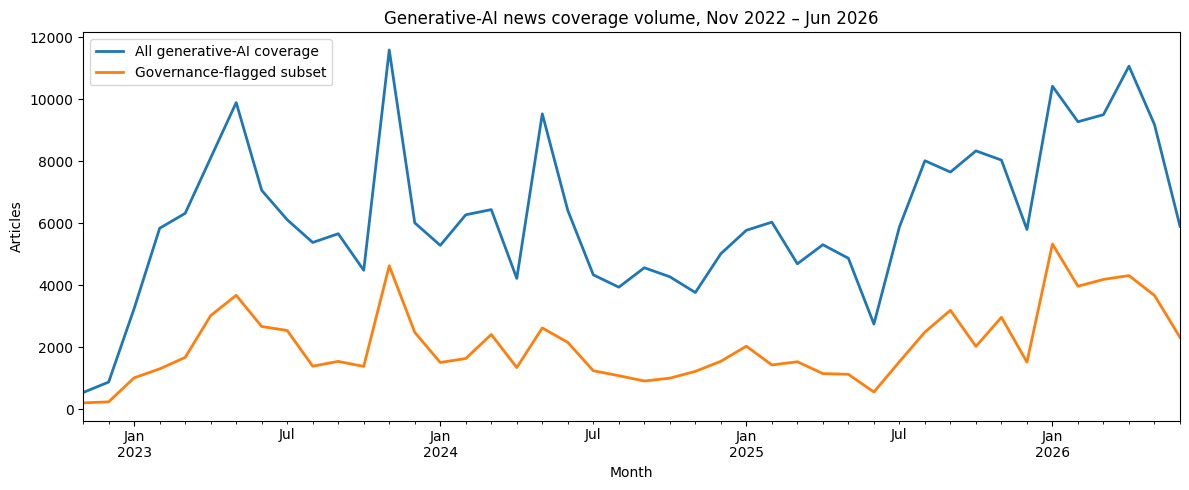

In [35]:
import matplotlib.pyplot as plt

# Monthly totals
monthly_all = df.groupby('month').size()
monthly_gov = df[df['governance_flag']==1].groupby('month').size()

# Drop the partial final month (June 2026) from the trend read
print("Monthly volume (full series):")
print(monthly_all)

fig, ax = plt.subplots(figsize=(12,5))
monthly_all.plot(ax=ax, label='All generative-AI coverage', linewidth=2)
monthly_gov.plot(ax=ax, label='Governance-flagged subset', linewidth=2)
ax.set_xlabel('Month'); ax.set_ylabel('Articles')
ax.set_title('Generative-AI news coverage volume, Nov 2022 – Jun 2026')
ax.legend()
ax.axvline(x=monthly_all.index.get_loc(pd.Period('2022-11')), color='gray', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/rq1_volume.png", dpi=150)
plt.show()

In [36]:
# Mark June 2026 as partial — exclude from the line or annotate
monthly_all = df.groupby('month').size()
monthly_gov = df[df['governance_flag']==1].groupby('month').size()

# Option: drop the partial final month for a clean trend
monthly_all_clean = monthly_all[:-1]   # excludes 2026-06
monthly_gov_clean = monthly_gov[:-1]

print("Peak months (all coverage):")
print(monthly_all.sort_values(ascending=False).head(5))

Peak months (all coverage):
month
2023-11    11587
2026-04    11065
2026-01    10418
2023-05     9891
2024-05     9527
Freq: M, dtype: int64


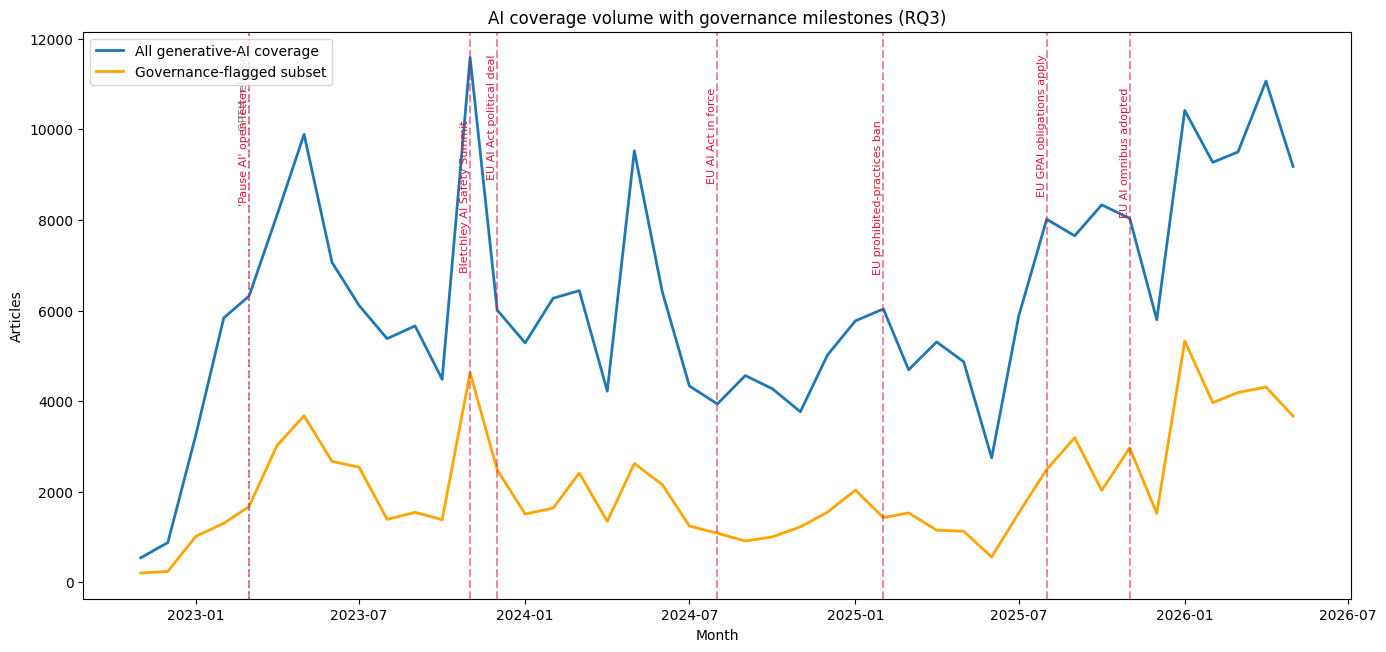

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert PeriodIndex to Timestamps so axvline and the line plot share coordinates
ma = monthly_all_clean.copy()
mg = monthly_gov_clean.copy()
ma.index = ma.index.to_timestamp()
mg.index = mg.index.to_timestamp()

fig, ax = plt.subplots(figsize=(15,7))
ax.plot(ma.index, ma.values, label='All generative-AI coverage', linewidth=2)
ax.plot(mg.index, mg.values, label='Governance-flagged subset', linewidth=2, color='orange')

ymax = ax.get_ylim()[1]
for i, (label, ym, mtype) in enumerate(MILESTONES):
    xdate = pd.Period(ym).to_timestamp()   # same coordinate system as the lines now
    color = 'crimson' if mtype=='governance' else 'gray'
    ls = '--' if mtype=='governance' else ':'
    ax.axvline(x=xdate, color=color, linestyle=ls, alpha=0.5)
    yheight = ymax * (0.96 - 0.06*(i % 3))
    ax.text(xdate, yheight, label, rotation=90, va='top', ha='right',
            fontsize=8, color=color)

ax.set_xlabel('Month'); ax.set_ylabel('Articles')
ax.set_title('AI coverage volume with governance milestones (RQ3)')
ax.legend(loc='upper left')
fig.subplots_adjust(top=0.92, right=0.97)
plt.savefig("/content/drive/MyDrive/rq3_milestone_overlay.png", dpi=150, bbox_inches='tight')
plt.show()

In [38]:
import ast
# Fix frames column if it got stringified by a CSV round-trip
if isinstance(df['frames'].iloc[0], str):
    df['frames'] = df['frames'].apply(ast.literal_eval)
    df['subthemes'] = df['subthemes'].apply(ast.literal_eval)
    print("Converted frames/subthemes back to lists.")
else:
    print("frames already lists — OK.")

frames already lists — OK.


In [39]:
FRAMES = ["innovation","risk","regulation","rights_privacy","economic_competition","misinformation"]
WINDOW = 3  # months each side

# precompute monthly frame prevalence (share of that month's articles invoking each frame)
def monthly_frame_share(frame):
    hit = df[df['frames'].apply(lambda f: frame in f)].groupby('month').size()
    return (hit / monthly_all).fillna(0)

shares = {f: monthly_frame_share(f) for f in FRAMES}

print(f"Frame prevalence shift: {WINDOW} months BEFORE vs AFTER each governance milestone")
print("(positive = frame became more prevalent after the milestone)\n")

for label, ym, mtype in MILESTONES:
    if mtype != "governance":
        continue
    center = pd.Period(ym)
    before = [center - i for i in range(1, WINDOW+1)]
    after  = [center + i for i in range(1, WINDOW+1)]
    print(f"--- {label} ({ym}) ---")
    for f in FRAMES:
        s = shares[f]
        b = s.reindex(before).mean()
        a = s.reindex(after).mean()
        if pd.isna(b) or pd.isna(a):
            continue
        delta = 100*(a-b)
        arrow = "↑" if delta>0 else "↓"
        print(f"   {f:22s} before {100*b:4.1f}%  after {100*a:4.1f}%  {arrow}{abs(delta):4.1f}pp")
    print()

Frame prevalence shift: 3 months BEFORE vs AFTER each governance milestone
(positive = frame became more prevalent after the milestone)

--- 'Pause AI' open letter (2023-03) ---
   innovation             before 18.0%  after 15.3%  ↓ 2.7pp
   risk                   before  5.9%  after  8.6%  ↑ 2.7pp
   regulation             before  6.3%  after 16.2%  ↑ 9.8pp
   rights_privacy         before  2.8%  after  4.1%  ↑ 1.3pp
   economic_competition   before 13.2%  after 12.1%  ↓ 1.1pp
   misinformation         before  1.5%  after  0.9%  ↓ 0.5pp

--- Bletchley AI Safety Summit (2023-11) ---
   innovation             before 18.9%  after 16.8%  ↓ 2.0pp
   risk                   before  5.5%  after  7.2%  ↑ 1.7pp
   regulation             before  7.6%  after 16.1%  ↑ 8.6pp
   rights_privacy         before  5.8%  after  7.0%  ↑ 1.3pp
   economic_competition   before 12.1%  after 12.2%  ↑ 0.1pp
   misinformation         before  0.7%  after  2.3%  ↑ 1.6pp

--- EU AI Act political deal (2023-12) ---


In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Make sure frames is a list (in case of CSV reload)
import ast
if isinstance(df['frames'].iloc[0], str):
    df['frames'] = df['frames'].apply(ast.literal_eval)

df['quarter'] = df['date'].dt.to_period('Q')

FRAMES = ["innovation","risk","regulation","rights_privacy","economic_competition","misinformation"]

# quarterly prevalence: share of that quarter's articles invoking each frame
q_total = df.groupby('quarter').size()
prev = pd.DataFrame({
    f: df[df['frames'].apply(lambda x: f in x)].groupby('quarter').size()
    for f in FRAMES
}).reindex(q_total.index).fillna(0)
prev_pct = prev.div(q_total, axis=0) * 100

# drop the partial final quarter (2026-Q2 is incomplete)
prev_pct_clean = prev_pct.iloc[:-1]

print("Frame prevalence by quarter (%):")
print(prev_pct_clean.round(1).to_string())

Frame prevalence by quarter (%):
         innovation  risk  regulation  rights_privacy  economic_competition  misinformation
quarter                                                                                    
2022Q4         15.2   3.7         3.3             1.0                   5.2             0.5
2023Q1         19.0   7.1         7.7             4.2                  15.3             1.3
2023Q2         15.0   8.7        16.4             4.0                  12.0             1.0
2023Q3         18.7   5.4        12.3             6.0                  12.2             1.3
2023Q4         15.4   6.0        10.3             4.2                  12.6             0.6
2024Q1         15.4   7.6        13.5             4.5                  11.1             3.1
2024Q2         17.9   4.8         7.4             4.1                  13.9             1.3
2024Q3         17.5   4.6         9.0             2.7                  15.6             2.4
2024Q4         17.0   4.7         8.1          

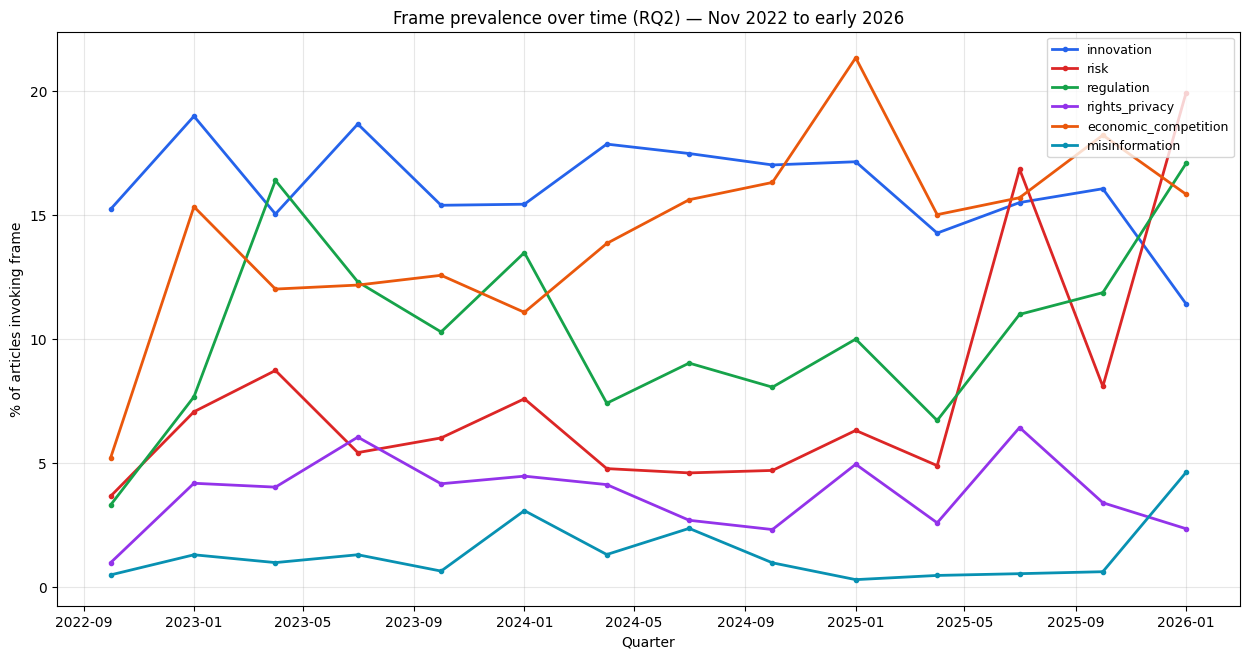

In [41]:
fig, ax = plt.subplots(figsize=(14,7))
x = prev_pct_clean.index.to_timestamp()

colors = {
    "innovation":"#2563eb", "risk":"#dc2626", "regulation":"#16a34a",
    "rights_privacy":"#9333ea", "economic_competition":"#ea580c",
    "misinformation":"#0891b2"
}
for f in FRAMES:
    ax.plot(x, prev_pct_clean[f], label=f, linewidth=2, color=colors[f], marker='o', markersize=3)

ax.set_xlabel('Quarter'); ax.set_ylabel('% of articles invoking frame')
ax.set_title('Frame prevalence over time (RQ2) — Nov 2022 to early 2026')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)
fig.subplots_adjust(right=0.97, top=0.93)
plt.savefig("/content/drive/MyDrive/rq2_frames_over_time.png", dpi=150, bbox_inches='tight')
plt.show()

In [42]:
# What's driving the risk surge in 2026Q1? Inspect the sub-themes
recent = df[(df['quarter']==pd.Period('2026Q1')) & (df['frames'].apply(lambda f: 'risk' in f))]
print(f"Risk-flagged articles in 2026Q1: {len(recent):,}")

# which risk sub-themes are firing
from collections import Counter
sub = Counter()
for subs in recent['subthemes']:
    sub.update([s for s in subs if s.startswith('risk:')])
print("\nRisk sub-theme breakdown:")
for s,c in sub.most_common():
    print(f"  {s:35s} {c:,}")

# sample 20 risk headlines to eyeball whether they're genuinely risk-framed
print("\n--- 20 sample risk headlines from 2026Q1 ---")
for h in recent['headline_text'].sample(20, random_state=7):
    print(" ", h)

Risk-flagged articles in 2026Q1: 5,818

Risk sub-theme breakdown:
  risk:security_cyber                 3,944
  risk:existential_safety             2,123
  risk:harm_to_vulnerable             590
  risk:reliability_hallucination      93

--- 20 sample risk headlines from 2026Q1 ---
  mom of one of musks kids sues xai over grok deepfakes
  openai ceo sam altman says pentagon deal looked opportunistic and sloppy
  anthropic refuses to bend to pentagon on ai safeguards as dispute nears deadline
  ai safeguards row puts anthropic s usd200 million deal at risk
  google s gemini chatbot dragged to court for california man s suicide
  musk grok child images
  ofcom investigating x after reports ai chatbot grok used to create sexualised images of children
  openai acquires cybersecurity startup promptfoo to boost ai agent security 020
  anthropic files lawsuit over pentagon ai supply chain ban
  anthropic pentagon standoff us credibility
  pentagon ai anthropic supply chain risk
  dow jones to